In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/sohailkhan05/house-price-prediction-advanced-regression/house_price_prediction_advanced_regression.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv("/kaggle/input/datasets/sohailkhan05/house-price-prediction-advanced-regression/house_price_prediction_advanced_regression.csv")
df = pd.DataFrame(data)
df.head()

,property_id,country,property_type,condition,bedrooms,bathrooms,floors,parking_spots,built_year,city,...,noise_5,noise_6,noise_7,noise_8,noise_9,noise_10,noise_11,noise_12,noise_13,noise_14
0,467853,UK,Villa,Luxury,1,2,3,3,1999,Birmingham,...,0.041490,0.903970,0.248306,0.652978,-0.543277,-0.757071,0.286868,-1.101469,-0.631376,0.548008
1,401997,Spain,Apartment,new,9,4,1,1,1982,Madrid,...,0.405441,-0.697392,-0.890734,2.024623,0.078306,1.398118,-0.326767,2.904358,-0.666788,0.126283
2,88436,Brazil,Apartment,Renovated,4,5,2,3,1957,Sao Paulo,...,-0.301511,0.131955,-0.976636,0.229704,1.358533,0.527816,-0.051949,1.541304,-0.009346,-0.129739
3,33855,Germany,Townhouse,Old,10,6,3,1,1967,Berlin,...,-0.234412,0.680395,-1.927466,0.496797,1.293100,1.018163,-1.218271,0.074830,1.012906,1.803595
4,222142,Canada,Penthouse,Old,7,6,2,0,1977,Montreal,...,-0.111238,1.638835,0.072931,-0.399528,-0.028257,-0.863598,-0.017557,-1.234406,0.019719,-1.259738


In [4]:
df.shape

(515000, 46)

In [5]:
df.columns

Index(['property_id', 'country', 'property_type', 'condition', 'bedrooms',
       'bathrooms', 'floors', 'parking_spots', 'built_year', 'city',
       'total_area', 'land_area', 'latitude', 'longitude', 'district',
       'postal_code', 'listing_date', 'interest_rate', 'inflation_index',
       'housing_index', 'luxury_demand_index', 'final_sale_price',
       'listing_price', 'price_per_sqm', 'currency', 'hoa_fee', 'property_tax',
       'days_on_market', 'price_revision_count', 'title', 'description',
       'noise_0', 'noise_1', 'noise_2', 'noise_3', 'noise_4', 'noise_5',
       'noise_6', 'noise_7', 'noise_8', 'noise_9', 'noise_10', 'noise_11',
       'noise_12', 'noise_13', 'noise_14'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515000 entries, 0 to 514999
Data columns (total 46 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   property_id           515000 non-null  int64  
 1   country               515000 non-null  object 
 2   property_type         515000 non-null  object 
 3   condition             515000 non-null  object 
 4   bedrooms              515000 non-null  int64  
 5   bathrooms             515000 non-null  int64  
 6   floors                515000 non-null  int64  
 7   parking_spots         515000 non-null  int64  
 8   built_year            515000 non-null  int64  
 9   city                  515000 non-null  object 
 10  total_area            515000 non-null  float64
 11  land_area             515000 non-null  float64
 12  latitude              515000 non-null  float64
 13  longitude             515000 non-null  float64
 14  district              515000 non-null  object 
 15  

In [7]:
col = ['property_id', 'country', 'property_type', 'condition', 'bedrooms',
       'bathrooms', 'floors', 'parking_spots', 'built_year', 'city',
       'total_area', 'land_area', 'latitude', 'longitude', 'district',
       'postal_code', 'listing_date', 'interest_rate', 'inflation_index',
       'housing_index', 'luxury_demand_index', 'final_sale_price',
       'listing_price', 'price_per_sqm', 'currency', 'hoa_fee', 'property_tax',
       'days_on_market', 'price_revision_count', 'title', 'description',
       'noise_0', 'noise_1', 'noise_2', 'noise_3', 'noise_4', 'noise_5',
       'noise_6', 'noise_7', 'noise_8', 'noise_9', 'noise_10', 'noise_11',
       'noise_12', 'noise_13', 'noise_14']
for cols in col:
    print(df[cols].head())

0    467853
1    401997
2     88436
3     33855
4    222142
Name: property_id, dtype: int64
0         UK
1      Spain
2     Brazil
3    Germany
4     Canada
Name: country, dtype: object
0        Villa
1    Apartment
2    Apartment
3    Townhouse
4    Penthouse
Name: property_type, dtype: object
0       Luxury
1          new
2    Renovated
3          Old
4          Old
Name: condition, dtype: object
0     1
1     9
2     4
3    10
4     7
Name: bedrooms, dtype: int64
0    2
1    4
2    5
3    6
4    6
Name: bathrooms, dtype: int64
0    3
1    1
2    2
3    3
4    2
Name: floors, dtype: int64
0    3
1    1
2    3
3    1
4    0
Name: parking_spots, dtype: int64
0    1999
1    1982
2    1957
3    1967
4    1977
Name: built_year, dtype: int64
0    Birmingham
1        Madrid
2     Sao Paulo
3        Berlin
4      Montreal
Name: city, dtype: object
0    107.259397
1    109.536126
2     34.497487
3     93.441801
4    393.361466
Name: total_area, dtype: float64
0    244.287460
1    260.826392
2

In [8]:
df.isnull().sum()

property_id             0
country                 0
property_type           0
condition               0
bedrooms                0
bathrooms               0
floors                  0
parking_spots           0
built_year              0
city                    0
total_area              0
land_area               0
latitude                0
longitude               0
district                0
postal_code             0
listing_date            0
interest_rate           0
inflation_index         0
housing_index           0
luxury_demand_index     0
final_sale_price        0
listing_price           0
price_per_sqm           0
currency                0
hoa_fee                 0
property_tax            0
days_on_market          0
price_revision_count    0
title                   0
description             0
noise_0                 0
noise_1                 0
noise_2                 0
noise_3                 0
noise_4                 0
noise_5                 0
noise_6                 0
noise_7     

In [9]:
df[df.duplicated()].head(10)

,property_id,country,property_type,condition,bedrooms,bathrooms,floors,parking_spots,built_year,city,...,noise_5,noise_6,noise_7,noise_8,noise_9,noise_10,noise_11,noise_12,noise_13,noise_14
4170,367736,Brazil,Apartment,New,10,3,1,2,1997,São Paulo,...,1.552604,-1.231948,-2.501993,0.832255,1.377510,-1.702447,-0.011848,0.870787,-0.593413,-0.885096
5782,326455,Spain,Studio,Under Construction,10,5,4,0,1993,Barcelona,...,2.002230,-0.485534,0.346587,0.942155,1.814336,0.048351,0.107084,0.186254,-0.222952,0.261209
6392,488023,Spain,Villa,New,1,1,2,1,1957,Barcelona,...,1.315410,0.118766,2.240789,-0.160233,0.701074,-0.199877,-1.535130,-1.539164,0.051010,1.949843
6920,416623,France,Villa,Needs Repair,3,3,3,3,1981,Paris,...,-1.282058,-2.615102,-1.195431,0.452326,-0.107367,0.938915,0.446014,-1.365394,1.032359,-0.215769
8010,273233,UK,Townhouse,new,9,2,4,3,1967,Birmingham,...,1.867305,-0.056433,0.022666,-2.437659,-1.436910,0.748226,-0.848677,-0.408962,-0.374344,2.965575
10172,293165,Spain,Villa,New,0,7,1,1,1996,Barcelona,...,1.133405,-0.587012,-1.388433,0.061398,-0.317398,1.519839,-0.074821,1.842263,1.804774,1.979227
10276,334165,Brazil,Villa,Renovated,7,1,3,3,1994,São Paulo,...,0.828058,-0.779130,-0.103450,-1.917983,0.508124,-0.973486,0.173460,0.722395,-2.026593,-0.730138
11295,455773,Australia,Condo,Luxury,11,2,4,0,1974,Brisbane,...,0.221043,-2.739623,-0.793373,0.868592,-1.644321,2.082419,1.223850,-1.096705,1.133416,0.424804
12101,467853,UK,Villa,Luxury,1,2,3,3,1999,Birmingham,...,0.041490,0.903970,0.248306,0.652978,-0.543277,-0.757071,0.286868,-1.101469,-0.631376,0.548008
12982,308022,Canada,Apartment,Under Construction,11,6,2,2,2009,Montreal,...,0.612852,0.531402,-0.496118,0.261058,-2.001818,1.880823,0.674590,0.225360,0.000388,0.758868


In [10]:
# 'District_435' this is district value and object dtype and as district is same throughtout this whole column , i would suggest to remove district and only put numbers here and change dtype from object to int.

# EDA

In [11]:
df.describe()

,property_id,bedrooms,bathrooms,floors,parking_spots,built_year,total_area,land_area,latitude,longitude,...,noise_5,noise_6,noise_7,noise_8,noise_9,noise_10,noise_11,noise_12,noise_13,noise_14
count,515000.000000,515000.000000,515000.000000,515000.000000,515000.000000,515000.000000,515000.000000,515000.000000,515000.000000,515000.000000,...,515000.000000,515000.000000,515000.000000,515000.000000,515000.000000,515000.000000,515000.000000,515000.000000,515000.000000,515000.000000
mean,249993.636066,5.503575,4.001695,2.500423,1.500528,1986.518041,565.668259,299.862578,-0.019391,-0.027405,...,0.003642,-0.001517,0.002930,-0.001614,0.000953,-0.001076,-0.000404,0.000205,0.001031,0.001831
std,144323.976267,3.452535,2.001683,1.118018,1.117430,21.355428,935.783495,236.470986,34.613436,86.631598,...,0.998681,1.000691,0.998574,1.001264,0.997501,0.999705,1.000402,1.000056,0.999926,0.998497
min,0.000000,0.000000,1.000000,1.000000,0.000000,1950.000000,-8370.764690,0.193698,-59.999821,-149.999783,...,-4.833167,-4.993069,-5.328562,-4.812680,-4.707785,-4.485990,-4.758258,-4.616214,-4.546697,-4.713989
25%,125015.750000,3.000000,2.000000,1.000000,1.000000,1968.000000,89.055486,131.292140,-30.032498,-75.161649,...,-0.669884,-0.675603,-0.668681,-0.676867,-0.672237,-0.677372,-0.674682,-0.672915,-0.674001,-0.672158
50%,249976.500000,6.000000,4.000000,3.000000,2.000000,1987.000000,179.695938,237.944546,0.031043,0.124559,...,0.004318,-0.002145,0.004436,-0.001739,0.001141,-0.000756,-0.001505,0.000821,0.000754,0.001657
75%,374982.250000,9.000000,6.000000,3.000000,2.000000,2005.000000,573.213408,401.430047,29.893220,74.864652,...,0.678685,0.672073,0.675303,0.673239,0.675031,0.672160,0.675023,0.674930,0.676208,0.674830
max,499999.000000,11.000000,7.000000,4.000000,3.000000,2023.000000,12657.317961,2529.913510,59.999990,149.999707,...,4.657584,4.626881,4.620889,4.480445,5.456263,4.852484,4.729143,4.656799,5.079031,4.370983


# univariate numerical

In [12]:
numeric_df = df.select_dtypes(include="number")
numeric_cols = df.select_dtypes(include='number').columns.tolist()
numeric_cols


['property_id',
 'bedrooms',
 'bathrooms',
 'floors',
 'parking_spots',
 'built_year',
 'total_area',
 'land_area',
 'latitude',
 'longitude',
 'postal_code',
 'interest_rate',
 'inflation_index',
 'housing_index',
 'luxury_demand_index',
 'final_sale_price',
 'price_per_sqm',
 'property_tax',
 'days_on_market',
 'price_revision_count',
 'noise_0',
 'noise_1',
 'noise_2',
 'noise_3',
 'noise_4',
 'noise_5',
 'noise_6',
 'noise_7',
 'noise_8',
 'noise_9',
 'noise_10',
 'noise_11',
 'noise_12',
 'noise_13',
 'noise_14']

In [13]:
# for col in numeric_cols:
#     plt.figure(figsize=(8,4))
#     plt.title(f"kde plot for {col}")
#     df[col].plot(kind="kde")
#     plt.show()

In [14]:
# numeric_cols
# for col in numeric_cols:
#     plt.figure(figsize=(8,4))
#     plt.title(f"histogram plot for {col}")
#     df[col].plot(kind="hist",bins=20)
#     plt.show()
    

In [15]:
 # for col in numeric_cols:
 #     plt.figure(figsize=(8,4))
 #     plt.title(f"box plot for {col}")
 #     df[col].plot(kind="box")
 #     plt.show()

# conclusion
Numerical EDA revealed discrete/count variables, right-skewed continuous variables, several outliers, physically invalid values in total_area, substantially different feature scales, and potentially suspicious values in price-related features. These issues require further investigation before preprocessing and modeling.

# categorical univariate

In [16]:
cat_df = df.select_dtypes(include="object")
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols

['country',
 'property_type',
 'condition',
 'city',
 'district',
 'listing_date',
 'listing_price',
 'currency',
 'hoa_fee',
 'title',
 'description']

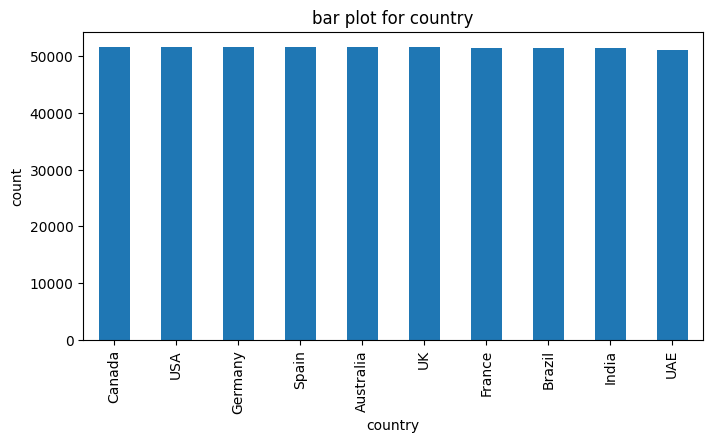

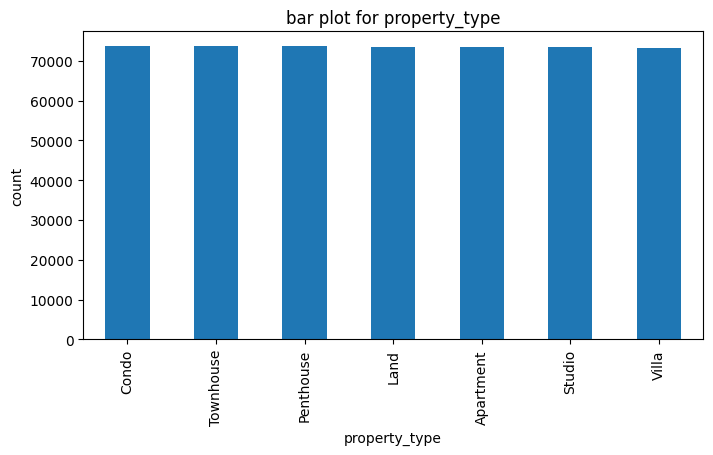

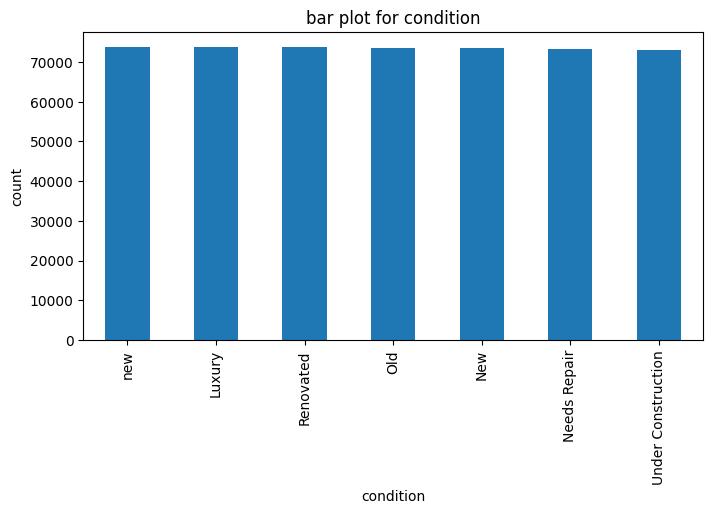

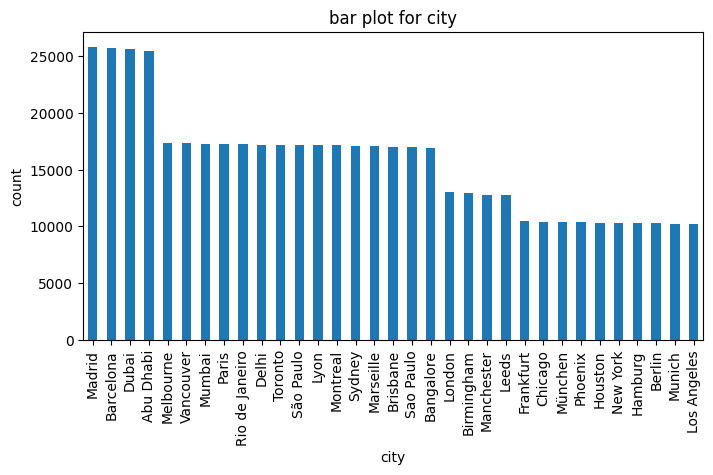

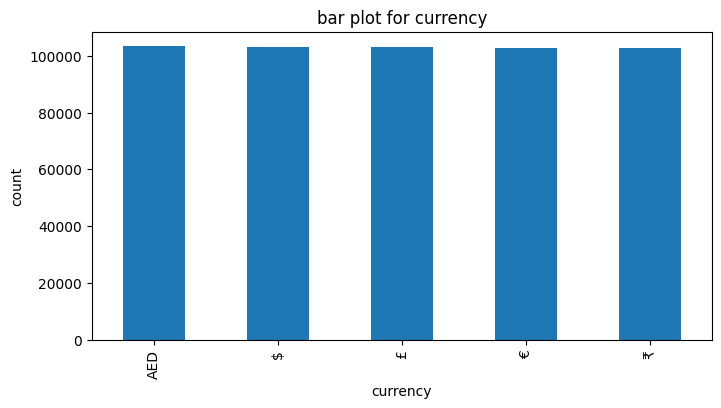

In [17]:
small_cat = ["country","property_type","condition","city","currency"]
for col in small_cat:
    plt.figure(figsize=(8,4))
    df[col].value_counts().plot(kind="bar")
    plt.xlabel(col)
    plt.ylabel("count")
    plt.title(f"bar plot for {col}")
    plt.show()

In [18]:
for col in cat_cols:
    print(df[col].value_counts())

country
Canada       51670
USA          51624
Germany      51615
Spain        51575
Australia    51552
UK           51497
France       51458
Brazil       51447
India        51433
UAE          51129
Name: count, dtype: int64
property_type
Condo        73731
Townhouse    73705
Penthouse    73620
Land         73559
Apartment    73547
Studio       73547
Villa        73291
Name: count, dtype: int64
condition
new                   73881
Luxury                73748
Renovated             73748
Old                   73598
New                   73550
Needs Repair          73376
Under Construction    73099
Name: count, dtype: int64
city
Madrid            25863
Barcelona         25712
Dubai             25644
Abu Dhabi         25485
Melbourne         17383
Vancouver         17329
Mumbai            17276
Paris             17245
Rio de Janeiro    17229
Delhi             17200
Toronto           17198
São Paulo         17183
Lyon              17164
Montreal          17143
Sydney            17132
Marsei

<Axes: xlabel='district'>

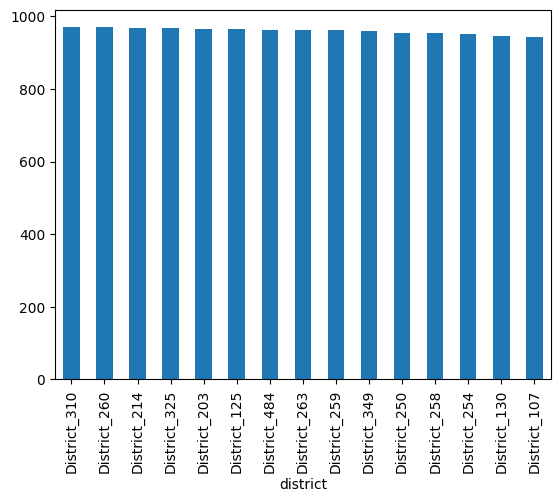

In [19]:
df["district"].nunique()
# df["district"].value_counts().head(15).plot(kind="bar")
df["district"].value_counts().tail(15).plot(kind="bar")


<Axes: xlabel='city'>

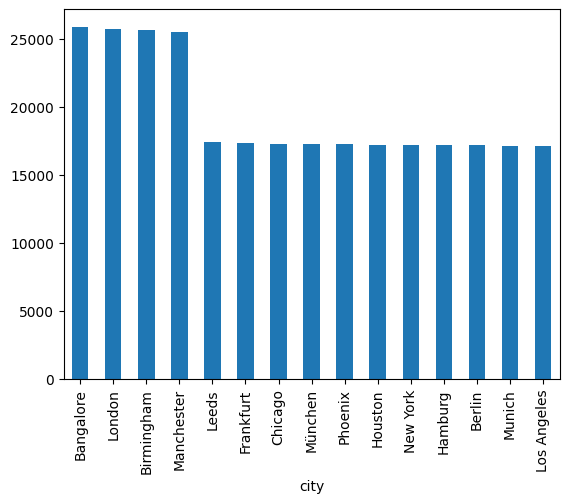

In [20]:
df["city"].nunique()
df["city"].value_counts().head(15).plot(kind="bar")
df["city"].value_counts().tail(15).plot(kind="bar")


<Axes: xlabel='hoa_fee'>

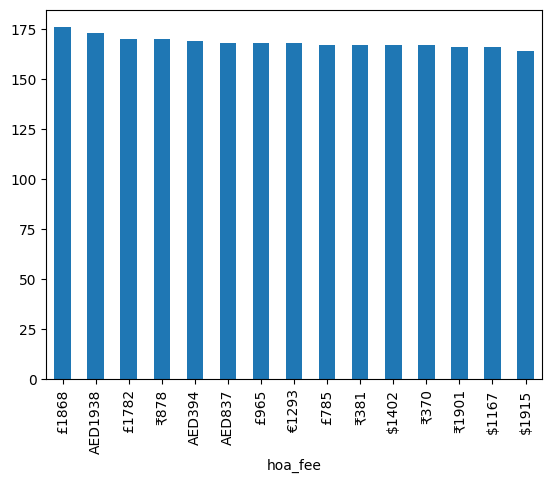

In [21]:
df["hoa_fee"].nunique()
df["hoa_fee"].value_counts().head(15).plot(kind="bar")
df["hoa_fee"].value_counts().tail(15).plot(kind="bar")

<Axes: xlabel='listing_price'>

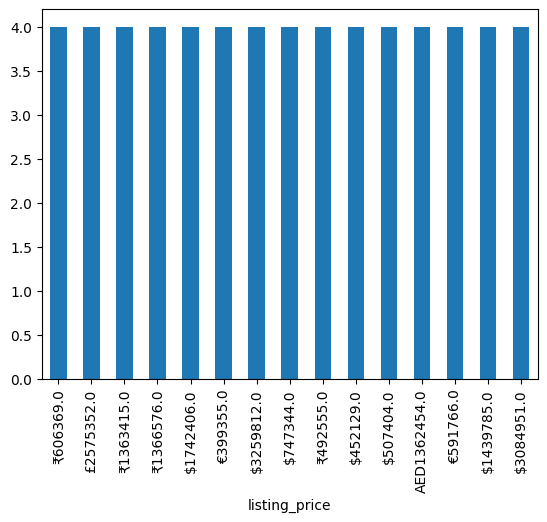

In [22]:
df["listing_price"].nunique()
df["listing_price"].value_counts().head(15).plot(kind="bar")
df["listing_price"].value_counts().tail(15).plot(kind="bar")

# conclusion
Categorical EDA revealed mostly balanced low-cardinality features, while city, district, and postal_code require special handling due to higher cardinality. postal_code is categorical despite its integer dtype, while listing_date is a datetime feature and title/description are text features excluded from this regression project.

# Numerical Bivariate

In [23]:
numeric_cols
half_col=[
 'built_year',
 'total_area',
 'land_area',
 'latitude',
 'longitude',
 'postal_code',
 'interest_rate',
 'inflation_index',
 'housing_index',
 'luxury_demand_index',
 'final_sale_price',
 'price_per_sqm',
 'property_tax',
 'days_on_market',
 'price_revision_count']

other_col=['property_id',
 'bedrooms',
 'bathrooms',
 'floors',
 'parking_spots']

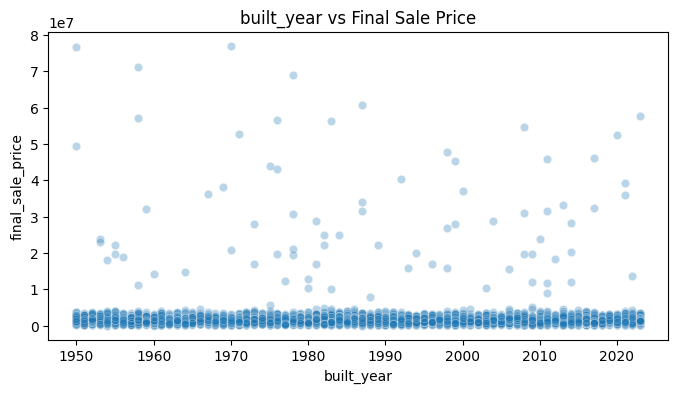

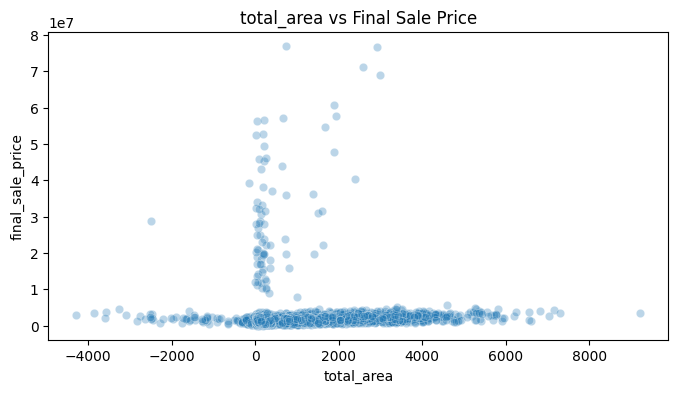

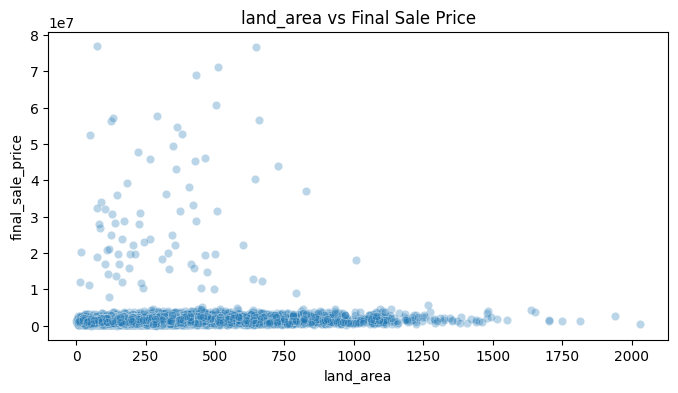

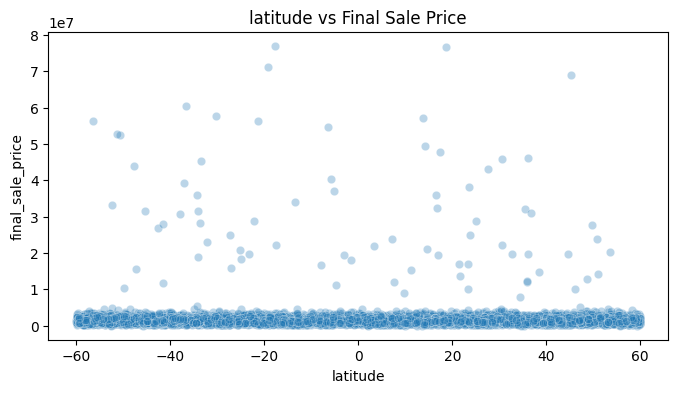

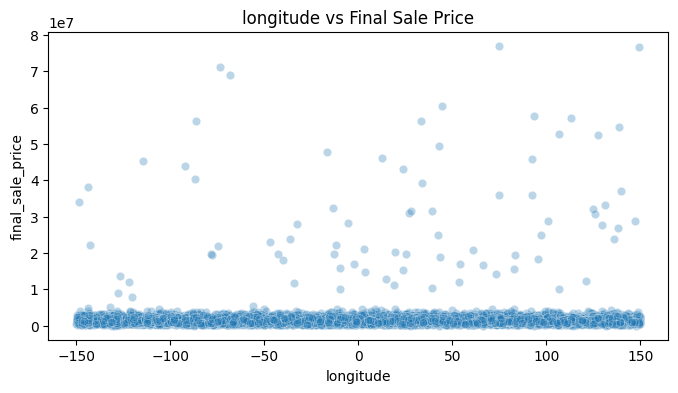

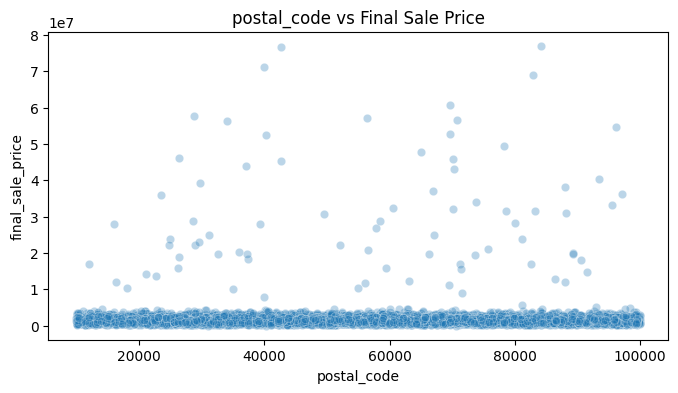

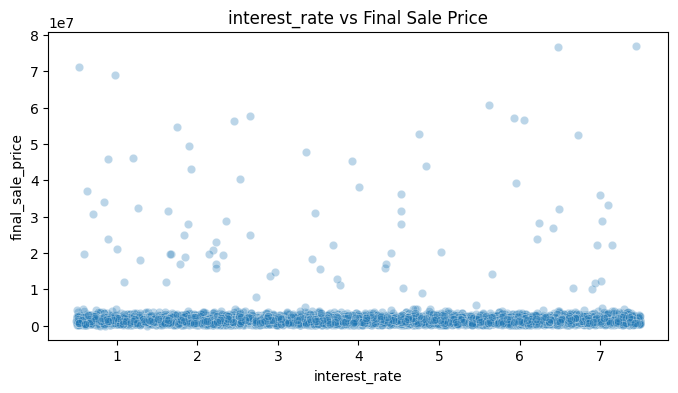

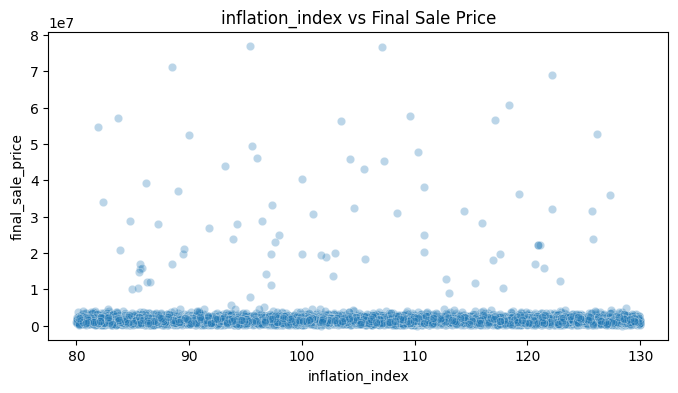

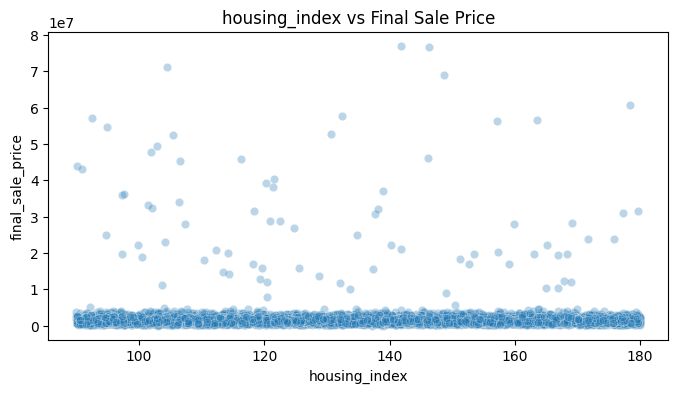

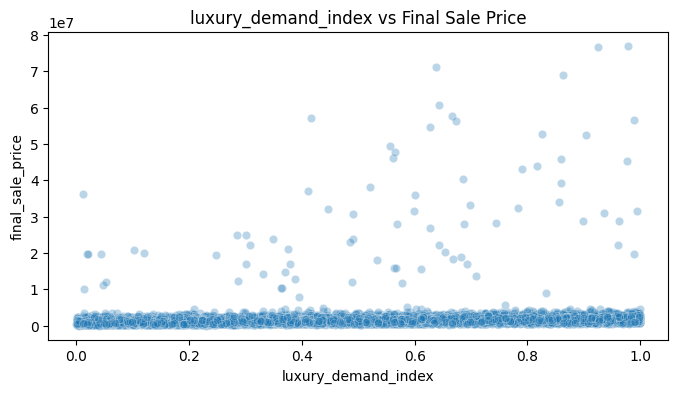

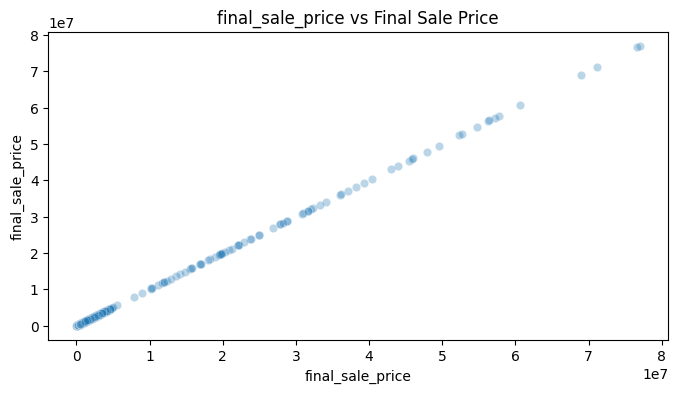

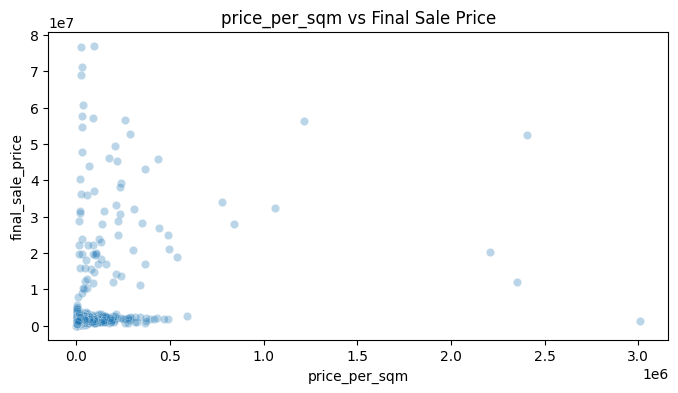

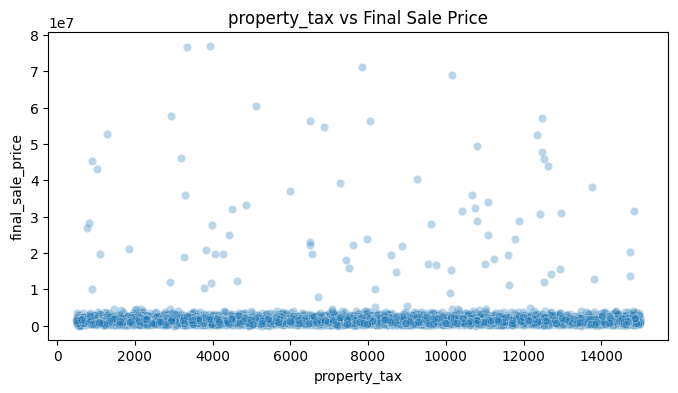

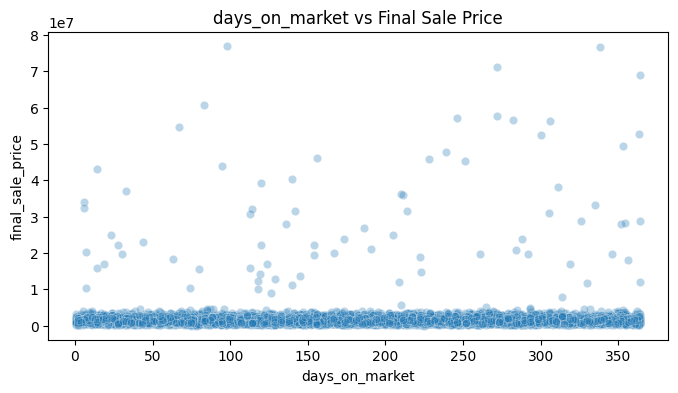

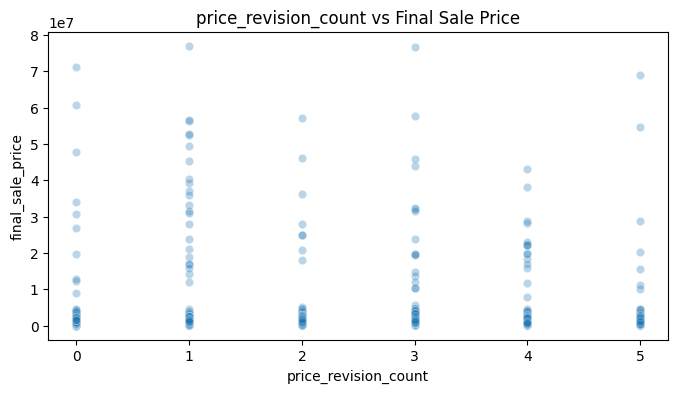

In [24]:
sample = df.sample(10000, random_state=42)

for col in half_col:
    plt.figure(figsize=(8, 4))
    sns.scatterplot(
        x=col,
        y="final_sale_price",
        data=sample,
        alpha=0.3
    )
    plt.title(f"{col} vs Final Sale Price")
    plt.show()

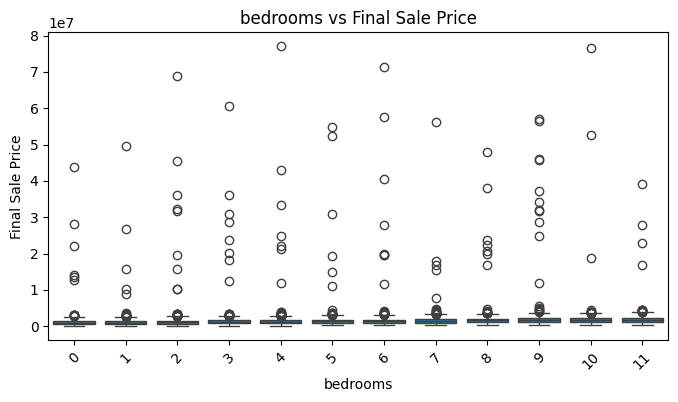

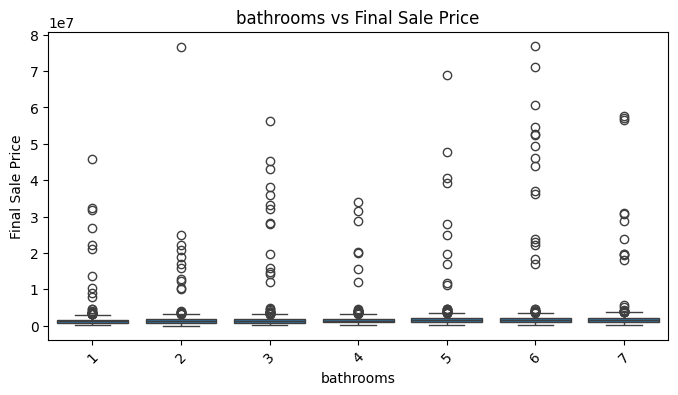

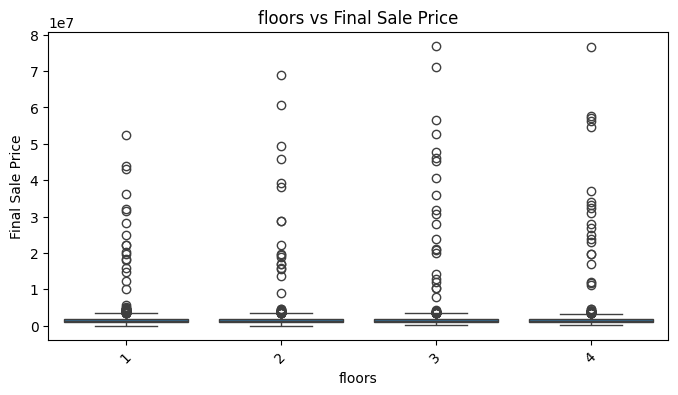

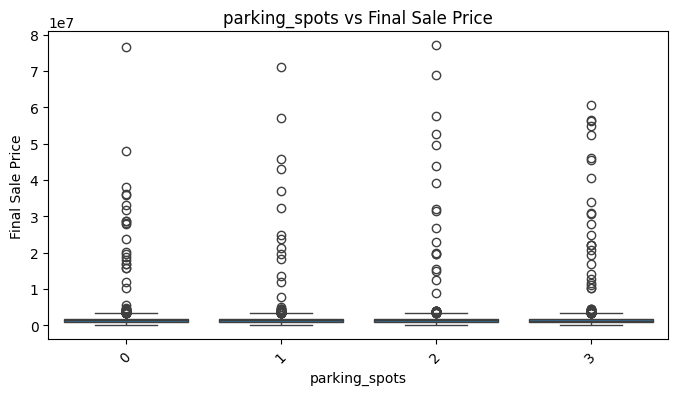

In [25]:
sample = df.sample(10000, random_state=42)

for col in other_col:
    if col == "property_id":
        continue

    plt.figure(figsize=(8, 4))

    sns.boxplot(
        data=sample,
        x=col,
        y="final_sale_price"
    )

    plt.title(f"{col} vs Final Sale Price")
    plt.xlabel(col)
    plt.ylabel("Final Sale Price")
    plt.xticks(rotation=45)
    plt.show()

# categorical Bivariate

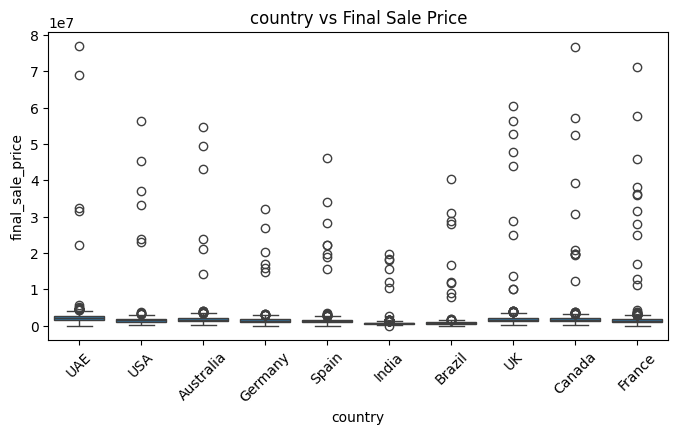

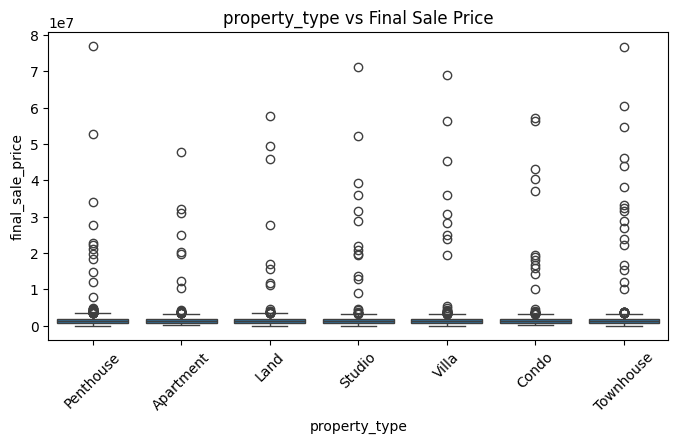

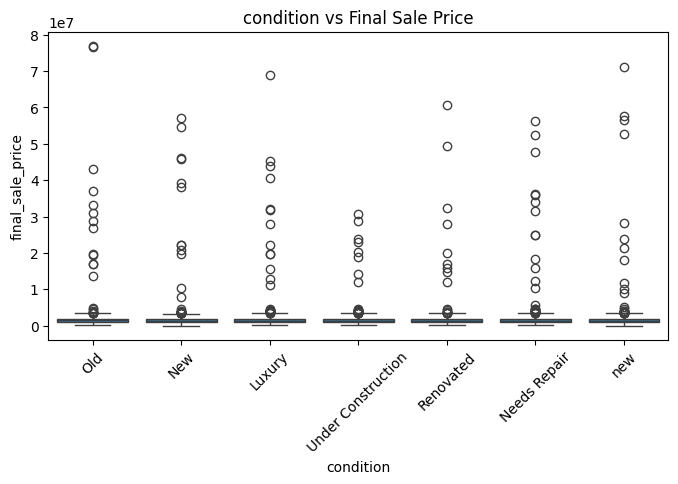

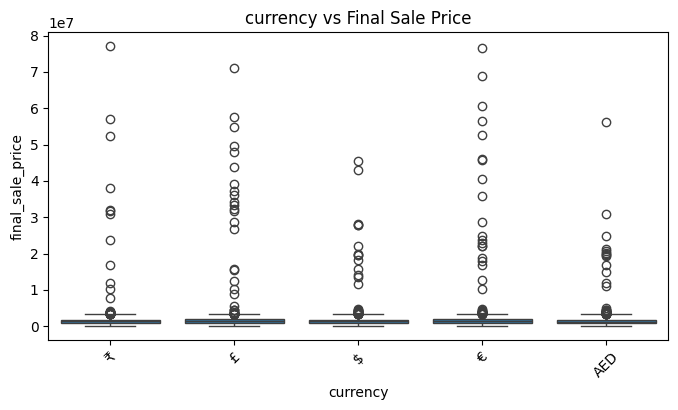

In [26]:
cat_cols = [
    "country",
    "property_type",
    "condition",
    "currency"
]

sample = df.sample(10000, random_state=42)

for col in cat_cols:
    plt.figure(figsize=(8, 4))

    sns.boxplot(
        data=sample,
        x=col,
        y="final_sale_price"
    )

    plt.title(f"{col} vs Final Sale Price")
    plt.xticks(rotation=45)
    plt.show()

In [27]:
high_col = ["city","district","listing_price","hoa_fee"]
for i in high_col:
     print(df[i].nunique())

33
499
490106
11400


In [28]:
for i in ["city", "district"]:
    counts = df[i].value_counts()
    

    print(f"\n{i}")
    print("Most frequent:", counts.max())
    print("Least frequent:", counts.min())
    print("Median frequency:", counts.median())


city
Most frequent: 25863
Least frequent: 10239
Median frequency: 17037.0

district
Most frequent: 1153
Least frequent: 944
Median frequency: 1031.0


In [29]:
for i in ["city", "district"]:
    counts = df[i].value_counts()
    print(f"\n{i}")
    print("Total categories:", len(counts))
    print("Categories appearing once:", (counts == 1).sum())
    print("Categories appearing <= 5 times:", (counts <= 5).sum())


city
Total categories: 33
Categories appearing once: 0
Categories appearing <= 5 times: 0

district
Total categories: 499
Categories appearing once: 0
Categories appearing <= 5 times: 0


# conclusion
The bivariate analysis of categorical features against final_sale_price shows considerable overlap in the target distributions across categories. The median sale prices and IQRs are generally similar for country, property_type, condition, and currency, although some variation in spread is observed, particularly across countries. All categories contain several potential high-value outliers.

city contains 33 categories with relatively balanced frequencies, while district contains 499 categories, making it a high-cardinality feature. Despite its high cardinality, the district frequencies are relatively uniform, with no extremely rare categories. Overall, the categorical features do not show strong separation in final_sale_price from the visual analysis alone. Further model-based evaluation will be required to determine their actual predictive usefulness.

# MULTIVARIATE ANALYSIS

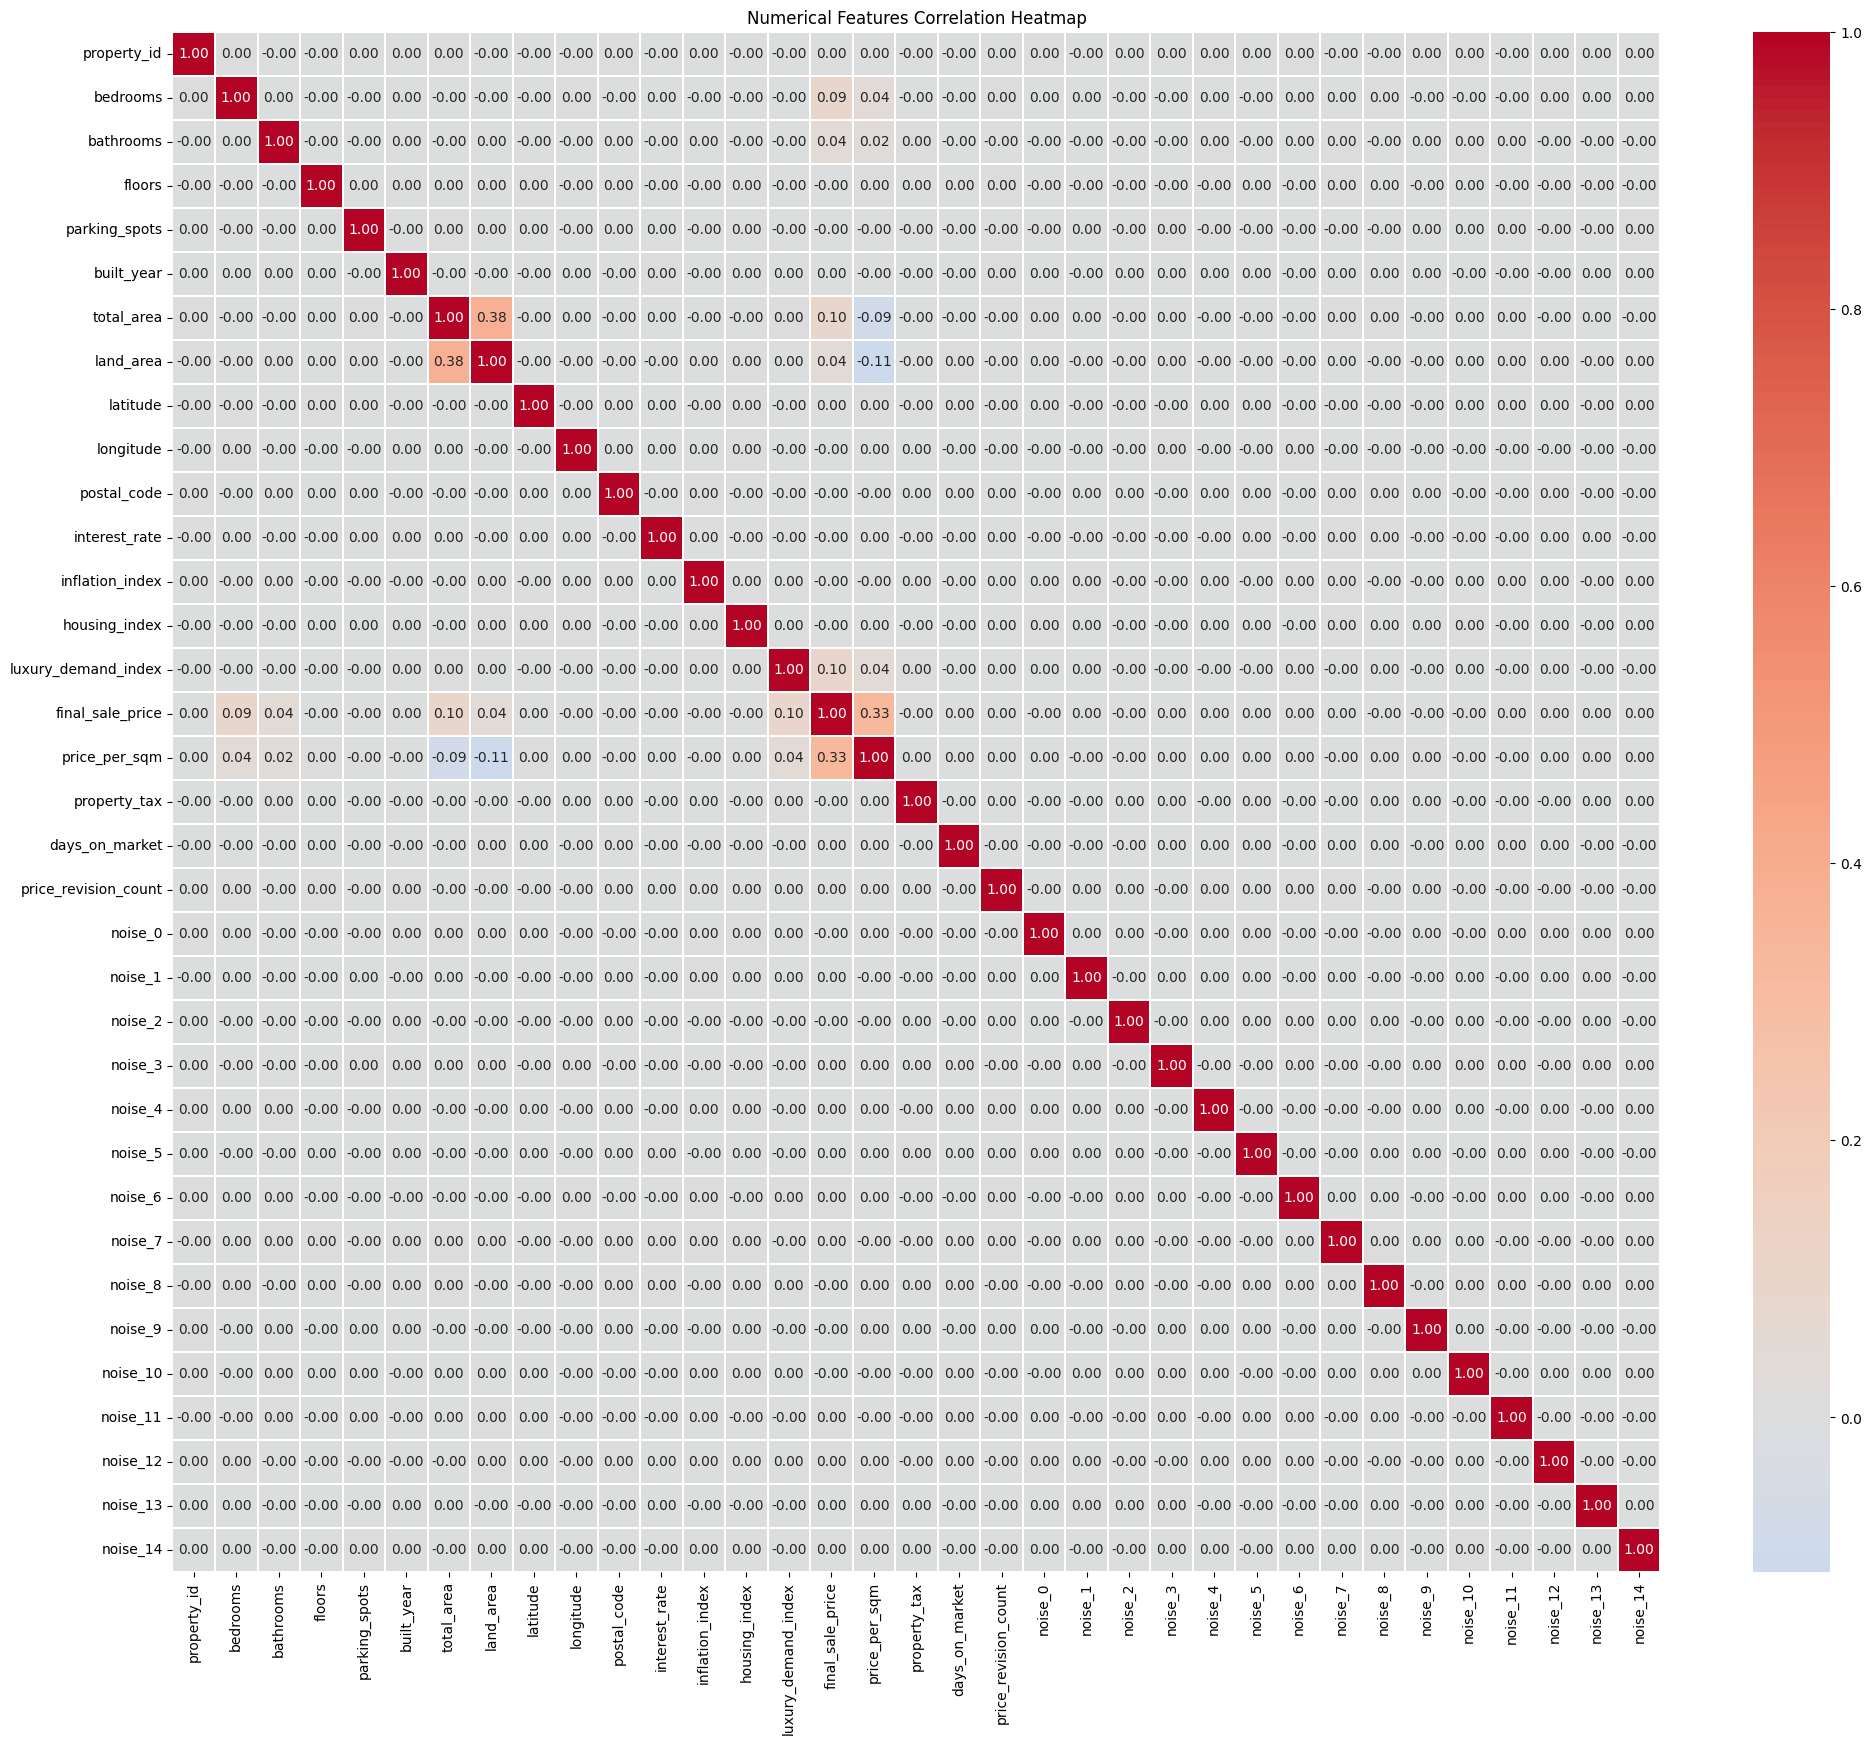

In [30]:
plt.figure(figsize=(24, 20))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.2
)

plt.title("Numerical Features Correlation Heatmap")
plt.show()


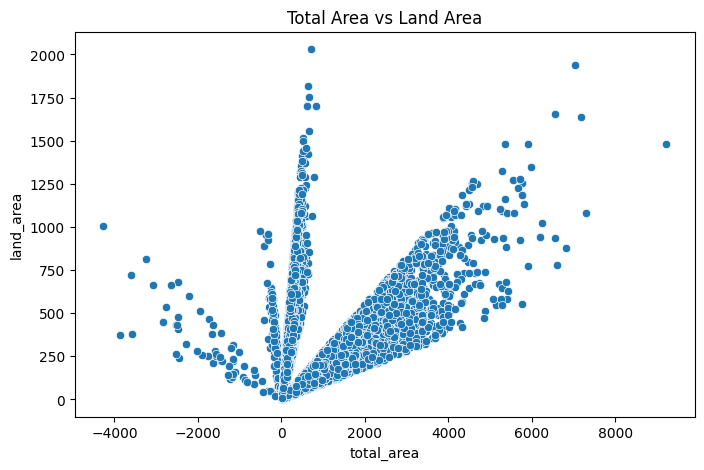

In [31]:
sample = df.sample(10000, random_state=42)

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=sample,
    x="total_area",
    y="land_area"
)

plt.title("Total Area vs Land Area")
plt.show()

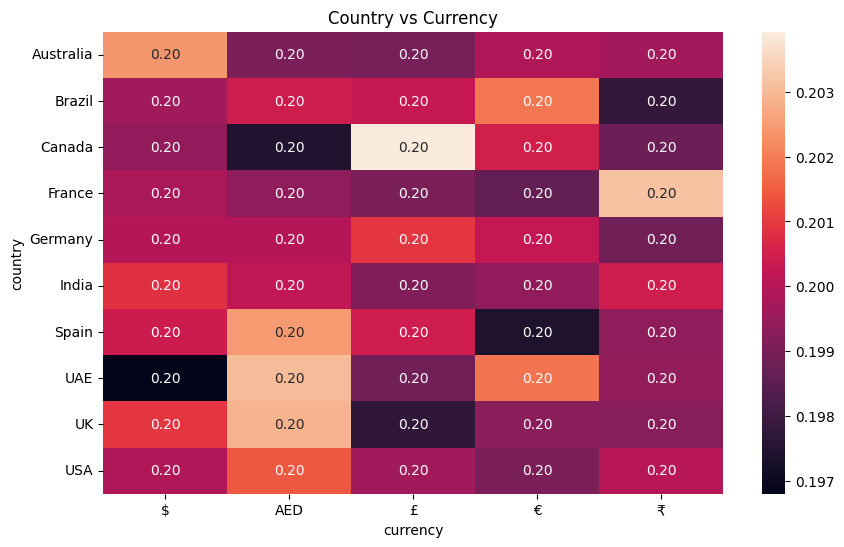

In [32]:
ct = pd.crosstab(
    df["country"],
    df["currency"],
    normalize="index"
)

plt.figure(figsize=(10, 6))

sns.heatmap(
    ct,
    annot=True,
    fmt=".2f"
)

plt.title("Country vs Currency")
plt.show()

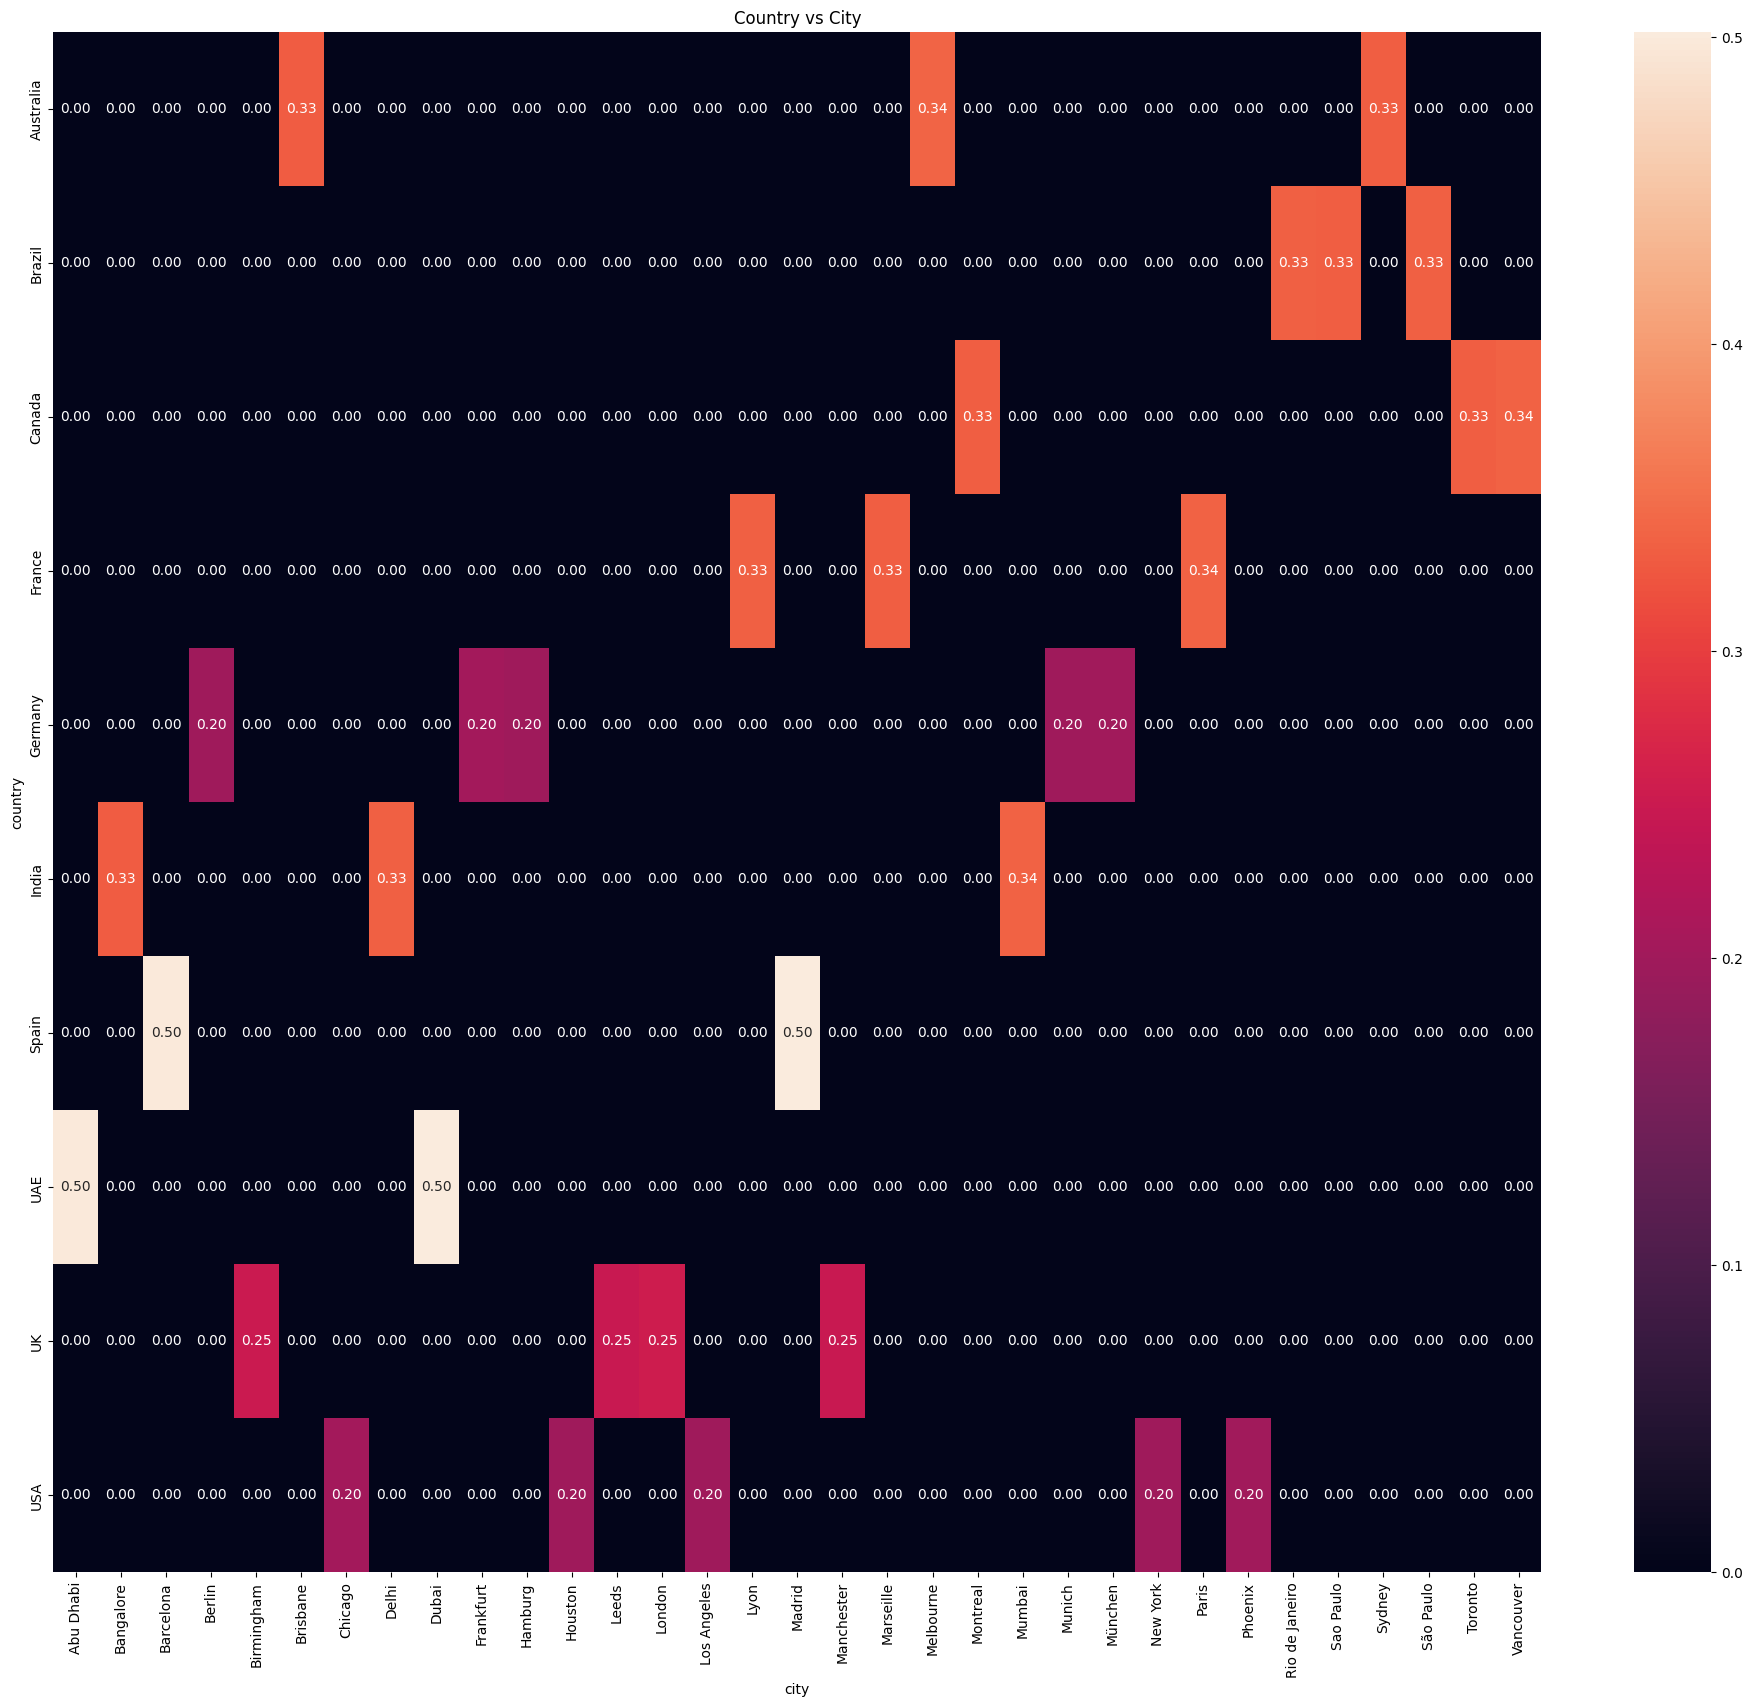

In [33]:
ct = pd.crosstab(
    df["country"],
    df["city"],
    normalize="index"
)

plt.figure(figsize=(24, 20))

sns.heatmap(
    ct,
    annot=True,
    fmt=".2f"
)

plt.title("Country vs City")
plt.show()

In [34]:
district_city = pd.crosstab(
    df["district"],
    df["city"]
)

district_city.max(axis=1).describe()

count    499.000000
mean      59.276553
std        5.406347
min       45.000000
25%       55.000000
50%       59.000000
75%       63.000000
max       80.000000
dtype: float64

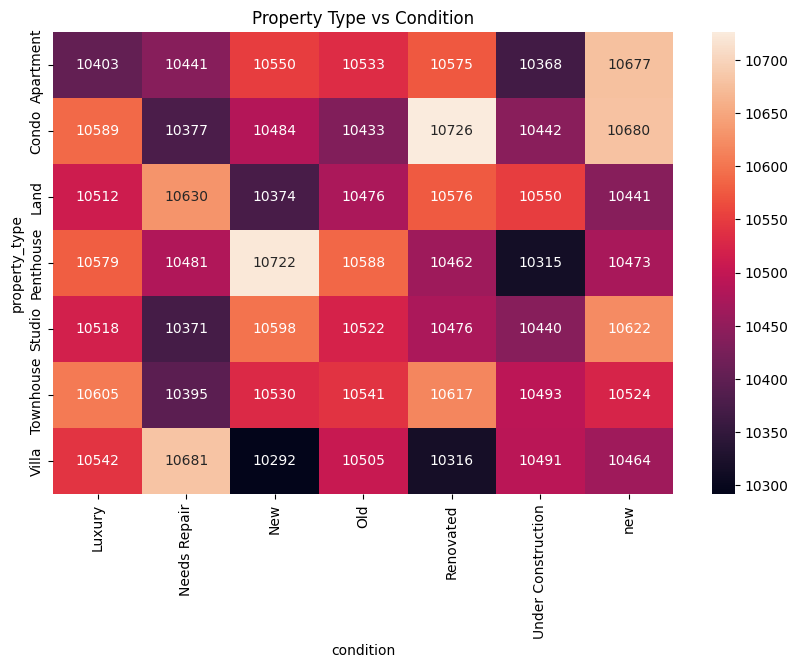

In [35]:
ct = pd.crosstab(
    df["property_type"],
    df["condition"]
)

plt.figure(figsize=(10, 6))

sns.heatmap(
    ct,
    annot=True,
    fmt="d"
)

plt.title("Property Type vs Condition")
plt.show()

In [36]:
dates = pd.to_datetime(df["listing_date"])

print("Earliest:", dates.min())
print("Latest:", dates.max())

Earliest: 2015-01-01 00:00:00
Latest: 2024-07-31 00:00:00


In [37]:
year_counts = dates.dt.year.value_counts().sort_index()

print(year_counts)

listing_date
2015    53769
2016    53933
2017    54188
2018    53346
2019    54142
2020    53814
2021    53374
2022    53578
2023    53657
2024    31199
Name: count, dtype: int64


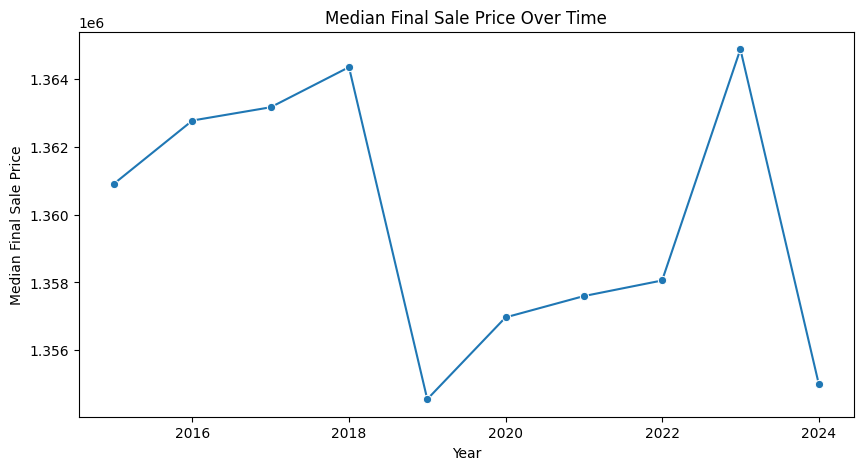

In [38]:
temp = df.copy()

temp["year"] = dates.dt.year

year_price = (
    temp.groupby("year")["final_sale_price"]
        .median()
        .reset_index()
)

plt.figure(figsize=(10, 5))

sns.lineplot(
    data=year_price,
    x="year",
    y="final_sale_price",
    marker="o"
)

plt.title("Median Final Sale Price Over Time")
plt.xlabel("Year")
plt.ylabel("Median Final Sale Price")

plt.show()

# Exploratory Data Analysis Conclusion

The dataset contains 515,000 observations and 46 initial features, with a mixture of numerical, categorical, datetime, identifier, and text variables. The dataset contains approximately 15,000 duplicate rows, but no missing values. Several data-quality and representation issues were identified, including negative values in total_area, inappropriate object datatypes for listing_date, listing_price, and hoa_fee, and identifier-like variables such as property_id and postal_code that should not be interpreted as continuous numerical features.

The numerical analysis showed that several variables are discrete/count-based, while continuous variables such as total_area, land_area, final_sale_price, and price_per_sqm exhibit skewness and extreme observations. total_area contains physically impossible negative values and therefore requires validation. land_area is positively skewed with high-end outliers. final_sale_price and other price-related variables also contain high-value observations that require investigation rather than automatic removal.

Bivariate analysis revealed that total_area, land_area, bathrooms, and luxury_demand_index show positive associations with final_sale_price, while bedrooms shows a weaker positive association. built_year, latitude, longitude, and price_revision_count showed relatively weak direct relationships with the target. The price_per_sqm feature showed an unusually strong relationship compared with most other variables and therefore requires a specific leakage investigation.

The noise_* variables showed approximately normal distributions and negligible linear correlations with the target, suggesting limited linear predictive information. However, their usefulness should ultimately be evaluated using model-based methods rather than correlation alone.

Categorical analysis showed that country, property_type, condition, and currency have relatively balanced category frequencies. city contains 33 categories with moderate frequency variation, while district contains 499 categories and is therefore high-cardinality, although its categories are relatively evenly represented. country and city showed a strong categorical association, while country and currency showed little obvious association in the normalized heatmap.

Temporal analysis revealed noticeable changes in median final_sale_price across listing years, including sharp decreases and increases during certain periods. This indicates that listing_date may contain useful temporal information and should be transformed into meaningful time-based features rather than treated as an ordinary categorical variable.

Overall, the EDA identified several important areas for preprocessing and modeling: duplicate handling, invalid-value treatment, datatype correction, potential target leakage, skewed numerical variables, high-cardinality categorical variables, datetime transformation, text-feature handling, and model-dependent scaling. The analysis also identified potentially useful numerical, categorical, geographic, and temporal information. No feature should be removed solely because of weak correlation or visual inspection; final feature usefulness should be validated through preprocessing, cross-validation, and model-based evaluation.

# Basic cleaning

In [39]:
df["list_date"] = pd.to_datetime(df["listing_date"] , format ="%Y-%m-%d")

In [40]:
df["property_id"].duplicated().sum()

np.int64(15000)

In [41]:
df.groupby("property_id").size().describe()

count    500000.000000
mean          1.030000
std           0.170587
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max           2.000000
dtype: float64

In [42]:
df[df["property_id"].duplicated(keep=False)].duplicated().sum()

np.int64(15000)

In [43]:
df = df.drop_duplicates().reset_index(drop=True)

In [44]:
df.duplicated().sum()

np.int64(0)

In [45]:
df["total_area"].describe()

count    500000.000000
mean        565.557036
std         935.323842
min       -8370.764690
25%          89.067768
50%         179.703038
75%         572.941410
max       12657.317961
Name: total_area, dtype: float64

In [46]:
(df["total_area"]<0).sum()

np.int64(10000)

In [47]:
df.loc[df["total_area"] < 0, "total_area"].describe()

count    10000.000000
mean      -582.075068
std        909.129140
min      -8370.764690
25%       -600.475780
50%       -186.856555
75%        -93.378009
max         -0.692088
Name: total_area, dtype: float64

In [48]:
df.loc[df["total_area"]<0,"total_area"] = np.nan

In [49]:
df["listing_price"].head(7)

0     ₹1022683.0
1     €1473924.0
2      £210200.0
3     £1042231.0
4     €2258618.0
5    AED808173.0
6     €1866074.0
Name: listing_price, dtype: object

In [50]:
df["final_sale_price"].value_counts()

final_sale_price
452352.85     2
1676298.55    2
1095773.72    2
2189741.75    2
946437.60     2
             ..
1172990.90    1
1688358.22    1
1341222.38    1
2037452.15    1
257287.80     1
Name: count, Length: 499480, dtype: int64

In [51]:
df.groupby("currency")["final_sale_price"].describe()

,count,mean,std,min,25%,50%,75%,max
currency,,,,,,,,
$,99955.0,1.743744e+06,3.794968e+06,527.27,877128.9300,1360156.08,1.879241e+06,1.307689e+08
AED,100235.0,1.724841e+06,3.663577e+06,131.43,874926.0450,1357153.39,1.880763e+06,1.141137e+08
£,99892.0,1.718027e+06,3.660708e+06,131.25,879142.8025,1364223.45,1.882159e+06,1.403947e+08
€,100011.0,1.757376e+06,3.828663e+06,1543.22,877292.9950,1361275.56,1.880327e+06,1.557775e+08
₹,99907.0,1.726075e+06,3.710877e+06,166.34,876104.3350,1357008.60,1.877999e+06,1.322293e+08


In [52]:
df["listing_price"].str.extract(r"([\d,.]+)").isna().sum()

0    0
dtype: int64

In [53]:
df["listing_price"] = df["listing_price"].str.extract(r"([\d,.]+)")[0]
df["listing_price_num"] = pd.to_numeric(df["listing_price"])

In [54]:
df["listing_price_num"].head(7)

0    1022683.0
1    1473924.0
2     210200.0
3    1042231.0
4    2258618.0
5     808173.0
6    1866074.0
Name: listing_price_num, dtype: float64

In [55]:
df["hoa_fee"].tail(10)

499990     €1787
499991      ₹897
499992      £667
499993     €1344
499994     $1176
499995     €1650
499996      1954
499997      1927
499998    AED479
499999       491
Name: hoa_fee, dtype: object

In [56]:
df.groupby("hoa_fee")["final_sale_price"].describe().head(10)

,count,mean,std,min,25%,50%,75%,max
hoa_fee,,,,,,,,
$100,27.0,1.167409e+06,7.146009e+05,311894.98,5.435127e+05,1005085.710,1.750008e+06,2619363.24
$1000,29.0,1.591637e+06,7.830622e+05,423177.67,1.082537e+06,1538409.850,2.003374e+06,3546704.52
$1001,31.0,1.286167e+06,5.893224e+05,13917.27,8.757897e+05,1285562.280,1.595196e+06,2681727.23
$1002,23.0,3.220704e+06,7.883466e+06,335246.90,1.062691e+06,1475847.100,2.106190e+06,39200695.90
$1003,25.0,1.420386e+06,8.086453e+05,330395.83,8.715057e+05,1391793.390,1.708424e+06,4332358.72
$1004,29.0,1.418839e+06,6.686240e+05,282975.33,8.496490e+05,1353258.700,1.864308e+06,2898521.06
$1005,29.0,1.379560e+06,7.992579e+05,427304.94,7.876812e+05,1182815.510,1.522354e+06,3650592.93
$1006,28.0,2.100290e+06,3.264472e+06,300250.54,1.077150e+06,1521291.885,1.966384e+06,18459913.32
$1007,30.0,1.502952e+06,7.789798e+05,220633.94,8.678619e+05,1529826.505,2.091455e+06,2957441.10


In [57]:
df["hoa_fee"] = df["hoa_fee"].str.extract(r"([\d,.]+)")[0]
df["hoa_fee_num"] = pd.to_numeric(df["hoa_fee"])

In [58]:
df["hoa_fee_num"].head(5)

0    1997
1     942
2    1662
3    1373
4    1590
Name: hoa_fee_num, dtype: int64

In [59]:
df["calc_price_sqm"] = (df["final_sale_price"]/df["total_area"])


In [60]:
diff = (df["calc_price_sqm"] - df["price_per_sqm"]).abs()
diff.describe()

count    4.900000e+05
mean     6.272890e+02
std      3.907302e+03
min      0.000000e+00
25%      2.903180e+01
50%      1.509266e+02
75%      5.326723e+02
max      1.452305e+06
dtype: float64

In [61]:
df["calc_price_sqm"].head(5)

0     9447.540661
1    14145.312469
2     6122.876105
3    11777.647569
4     6040.590917
Name: calc_price_sqm, dtype: float64

In [62]:
df["price_per_sqm"].head(5)

0     9534.666397
1    13456.050453
2     6093.184439
3    11777.647569
4     5741.839663
Name: price_per_sqm, dtype: float64

In [63]:
df["calculated_listing_ppsm"] = (
    df["listing_price_num"] / df["total_area"]
)

In [64]:
difference_listing = (
    df["price_per_sqm"] - df["calculated_listing_ppsm"]
).abs()

difference_listing.describe()

count    4.900000e+05
mean     1.140902e+02
std      1.992743e+03
min      1.115427e-08
25%      3.295143e-04
50%      1.453355e-03
75%      4.775883e-03
max      6.425566e+05
dtype: float64

In [65]:
relative_diff = (
    (df["price_per_sqm"] - df["calculated_listing_ppsm"]).abs()
    / df["calculated_listing_ppsm"]
)

relative_diff.describe()

count    4.900000e+05
mean     7.453117e-03
std      2.114804e-02
min      2.630280e-12
25%      1.006755e-07
50%      2.127618e-07
75%      4.663934e-07
max      1.111035e-01
dtype: float64

In [66]:
(relative_diff < 0.001).mean()*100

np.float64(83.60220000000001)

In [67]:
df["total_area"].isna().sum()

np.int64(10000)

# CONCLUSION 
The dataset initially contained several data-quality and structural issues that needed to be addressed before preprocessing and model training.

First, the listing_date column was stored as an object, so it was converted to a proper datetime datatype. The dataset contained 15,000 exact duplicate rows, which were verified by checking duplicated property_id values and comparing the complete rows. Since they contained no additional information, the duplicate rows were removed.

total_area contained 10,000 negative values (~2%). Since negative property area is physically impossible, these values were treated as invalid rather than deleting the entire observations. Only the invalid feature values were replaced with NaN, allowing the remaining information in those rows to be preserved for later imputation.

listing_price and hoa_fee were stored as formatted strings rather than numerical values. Their numerical components were extracted and converted into numeric datatypes so they can be used during modeling.

price_per_sqm was investigated for possible target leakage. It was compared against both final_sale_price / total_area and listing_price / total_area. It did not consistently match the target-derived calculation, while approximately 83% of observations were within 0.1% of the listing-price-derived calculation, suggesting that the feature is primarily derived from information available at listing time rather than directly from the target. Therefore, it was retained temporarily and will be evaluated for redundancy during modeling.

Currency distributions were also investigated. The target's distribution was broadly similar across currencies, so no arbitrary currency conversion was applied. currency will be treated as a categorical feature.

Identifier and special-purpose columns were also identified. property_id will not be used as a predictive feature, postal_code will be treated as categorical/location information, and title and description will be reserved for a future NLP workflow.

Outliers, skewness, high-cardinality categorical variables, missing-value imputation, encoding, scaling, and feature transformations were intentionally not handled during basic cleaning. These will be addressed during the preprocessing stage.

Therefore, the dataset is now structurally cleaned and ready for preprocessing.

# SPLIT


In [68]:
df.head()

,property_id,country,property_type,condition,bedrooms,bathrooms,floors,parking_spots,built_year,city,...,noise_10,noise_11,noise_12,noise_13,noise_14,list_date,listing_price_num,hoa_fee_num,calc_price_sqm,calculated_listing_ppsm
0,467853,UK,Villa,Luxury,1,2,3,3,1999,Birmingham,...,-0.757071,0.286868,-1.101469,-0.631376,0.548008,2020-06-28,1022683.0,1997,9447.540661,9534.670463
1,401997,Spain,Apartment,new,9,4,1,1,1982,Madrid,...,1.398118,-0.326767,2.904358,-0.666788,0.126283,2024-05-20,1473924.0,942,14145.312469,13456.053749
2,88436,Brazil,Apartment,Renovated,4,5,2,3,1957,Sao Paulo,...,0.527816,-0.051949,1.541304,-0.009346,-0.129739,2018-10-20,210200.0,1662,6122.876105,6093.197422
3,33855,Germany,Townhouse,Old,10,6,3,1,1967,Berlin,...,1.018163,-1.218271,0.074830,1.012906,1.803595,2015-08-11,1042231.0,1373,11777.647569,11153.798292
4,222142,Canada,Penthouse,Old,7,6,2,0,1977,Montreal,...,-0.863598,-0.017557,-1.234406,0.019719,-1.259738,2022-02-05,2258618.0,1590,6040.590917,5741.838471


In [69]:
df.columns

Index(['property_id', 'country', 'property_type', 'condition', 'bedrooms',
       'bathrooms', 'floors', 'parking_spots', 'built_year', 'city',
       'total_area', 'land_area', 'latitude', 'longitude', 'district',
       'postal_code', 'listing_date', 'interest_rate', 'inflation_index',
       'housing_index', 'luxury_demand_index', 'final_sale_price',
       'listing_price', 'price_per_sqm', 'currency', 'hoa_fee', 'property_tax',
       'days_on_market', 'price_revision_count', 'title', 'description',
       'noise_0', 'noise_1', 'noise_2', 'noise_3', 'noise_4', 'noise_5',
       'noise_6', 'noise_7', 'noise_8', 'noise_9', 'noise_10', 'noise_11',
       'noise_12', 'noise_13', 'noise_14', 'list_date', 'listing_price_num',
       'hoa_fee_num', 'calc_price_sqm', 'calculated_listing_ppsm'],
      dtype='object')

In [70]:
drop_col = ["property_id",'title', 'description',
       'noise_0', 'noise_1', 'noise_2', 'noise_3', 'noise_4', 'noise_5',
       'noise_6', 'noise_7', 'noise_8', 'noise_9', 'noise_10', 'noise_11',
       'noise_12', 'noise_13', 'noise_14']
df.drop(columns=drop_col, inplace=True)

In [71]:
df

,country,property_type,condition,bedrooms,bathrooms,floors,parking_spots,built_year,city,total_area,...,currency,hoa_fee,property_tax,days_on_market,price_revision_count,list_date,listing_price_num,hoa_fee_num,calc_price_sqm,calculated_listing_ppsm
0,UK,Villa,Luxury,1,2,3,3,1999,Birmingham,107.259397,...,₹,1997,4011.473375,151,2,2020-06-28,1022683.0,1997,9447.540661,9534.670463
1,Spain,Apartment,new,9,4,1,1,1982,Madrid,109.536126,...,€,942,1573.577612,100,1,2024-05-20,1473924.0,942,14145.312469,13456.053749
2,Brazil,Apartment,Renovated,4,5,2,3,1957,Sao Paulo,34.497487,...,£,1662,11689.432091,320,0,2018-10-20,210200.0,1662,6122.876105,6093.197422
3,Germany,Townhouse,Old,10,6,3,1,1967,Berlin,93.441801,...,£,1373,3344.736306,199,4,2015-08-11,1042231.0,1373,11777.647569,11153.798292
4,Canada,Penthouse,Old,7,6,2,0,1977,Montreal,393.361466,...,€,1590,13044.199880,109,4,2022-02-05,2258618.0,1590,6040.590917,5741.838471
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499995,UAE,Condo,Old,0,2,2,1,1971,Dubai,542.309804,...,€,1650,12279.473183,132,4,2020-11-03,1048687.0,1650,1899.385854,1933.741549
499996,Spain,Townhouse,Old,5,3,2,0,1962,Madrid,13.815955,...,€,1954,13728.638341,29,4,2022-10-31,1291190.0,1954,89222.744781,93456.443487
499997,Canada,Penthouse,Luxury,7,3,2,1,1953,Montreal,375.206541,...,$,1927,4487.280897,232,3,2023-06-04,1382935.0,1927,3415.218660,3685.796619
499998,France,Condo,New,3,2,3,0,1952,Marseille,137.016643,...,AED,479,11039.105063,355,1,2019-04-09,800822.0,479,6082.563407,5844.706026


In [72]:
df2 = df.copy()

In [119]:
df2["postal_code"] = df2["postal_code"].astype("object")

In [73]:
X = df2.drop(columns="final_sale_price")
y = df2["final_sale_price"]

In [74]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [125]:
X.drop(columns = ["calc_price_sqm","calculated_listing_ppsm"],inplace=True)

In [127]:
X.shape

(500000, 30)

# preprocessing

In [129]:
X.isna().sum()

country                     0
property_type               0
condition                   0
bedrooms                    0
bathrooms                   0
floors                      0
parking_spots               0
built_year                  0
city                        0
total_area              10000
land_area                   0
latitude                    0
longitude                   0
district                    0
postal_code                 0
listing_date                0
interest_rate               0
inflation_index             0
housing_index               0
luxury_demand_index         0
listing_price               0
price_per_sqm               0
currency                    0
hoa_fee                     0
property_tax                0
days_on_market              0
price_revision_count        0
list_date                   0
listing_price_num           0
hoa_fee_num                 0
dtype: int64

In [99]:
#  imputation  total area needs log1p , 
num_df = df2.select_dtypes(include="number")
num2_cols = df2.select_dtypes(include='number').columns.tolist()
num2_cols
for i in num2_cols:
    print(df2[i].skew())

-0.00016075578900718305
-0.0017561812973044193
-0.001669210728369265
-0.0008676570274114456
-0.0015779792824595212
2.6729908979145187
1.7463701223533812
-0.000545960574625655
-0.0015799305830673253
-0.0003254807571558674
-0.0013473554048028977
0.0002534198583424209
-0.0025964046624364283
-0.0023412534792698844
14.280986130804422
113.92449315893874
0.0014504893993888292
-0.0019726096634937475
-0.0007643190481944854
14.345031598006946
0.0006287452310438015
122.46631672315218
115.08053182674914


In [100]:
num2_cols

['bedrooms',
 'bathrooms',
 'floors',
 'parking_spots',
 'built_year',
 'total_area',
 'land_area',
 'latitude',
 'longitude',
 'postal_code',
 'interest_rate',
 'inflation_index',
 'housing_index',
 'luxury_demand_index',
 'final_sale_price',
 'price_per_sqm',
 'property_tax',
 'days_on_market',
 'price_revision_count',
 'listing_price_num',
 'hoa_fee_num',
 'calc_price_sqm',
 'calculated_listing_ppsm']

In [101]:
y.skew()

np.float64(14.280986130804422)

In [92]:
# property type,condition,currency one hot , country i can maybe drop as it is not giving me much info , city district and postal_code needs diff method as one hot encoding creates unneceesary more columns.
X["district"].value_counts()

district
District_33     1111
District_74     1096
District_357    1087
District_453    1086
District_45     1086
                ... 
District_203     929
District_259     929
District_254     925
District_107     921
District_130     913
Name: count, Length: 499, dtype: int64

In [109]:
df["city"].head(30)

0         Birmingham
1             Madrid
2          Sao Paulo
3             Berlin
4           Montreal
5          Melbourne
6          Abu Dhabi
7            Toronto
8          Barcelona
9          São Paulo
10           Toronto
11            Madrid
12            Munich
13          New York
14             Dubai
15          New York
16           Phoenix
17            Madrid
18            Mumbai
19         Abu Dhabi
20         Marseille
21         Vancouver
22        Birmingham
23          Brisbane
24            Sydney
25    Rio de Janeiro
26         Marseille
27         Marseille
28         Marseille
29            London
Name: city, dtype: object

In [ ]:
postal code i can do binning maybe

In [118]:
df2.groupby("postal_code")["district"].nunique().describe()

count    89653.000000
mean         5.545871
std          2.313957
min          1.000000
25%          4.000000
50%          5.000000
75%          7.000000
max         18.000000
Name: district, dtype: float64

# conclusion
After completing the basic cleaning and train-test split, a preprocessing strategy was designed based on the characteristics of each feature rather than applying the same transformation to all columns.

For numerical features, total_area will undergo median imputation because it contains the only missing values and is highly skewed. The strongly right-skewed numerical features — total_area, land_area, listing_price_numeric, and price_per_sqm — will be transformed using log1p. Features with approximately normal distributions will remain unchanged. Scaling will be decided later based on the models being evaluated.

The target final_sale_price will be handled separately from the feature preprocessing pipeline. Its high skewness will be addressed after the train-test split, and the benefit of target transformation will be validated experimentally rather than assumed.

For categorical variables, low-cardinality features such as country, property_type, condition, and currency, along with city, will use One-Hot Encoding. district and postal_code have much higher cardinality, so frequency encoding was selected as a candidate to avoid unnecessarily expanding the feature space.

Frequency encoding will calculate the proportion of each category using training data only. The learned mapping will then be applied to both training and test data, with unseen categories receiving a frequency of 0. This prevents preprocessing leakage and keeps the transformation consistent.

The relationship between city, district, and postal_code was investigated rather than assuming a geographic hierarchy. The results showed that city and district do not have a meaningful hierarchical mapping in this dataset, while district and postal_code have a partial relationship but are not one-to-one.

The preprocessing strategy is now defined. The next step is implementation using a ColumnTransformer, custom frequency encoder, and eventually a complete sklearn Pipeline.

# PREPROCESSING PIPELINES

**non scaled pipeline**

In [137]:
imputer = ["total_area"]
skewed = ["land_area","listing_price_num","price_per_sqm"]
other_ncol = ['bedrooms',
 'bathrooms',
 'floors',
 'parking_spots',
 'built_year',
 'latitude',
 'longitude',
 'interest_rate',
 'inflation_index',
 'housing_index',
 'luxury_demand_index',
 'property_tax',
 'days_on_market',
 'price_revision_count',
 'hoa_fee_num']

OHE = ["country","property_type","condition","currency","city"]

freq = ["district","postal_code"]

In [138]:
df2["listing_price_num"].head()

0    1022683.0
1    1473924.0
2     210200.0
3    1042231.0
4    2258618.0
Name: listing_price_num, dtype: float64

In [139]:
from sklearn.preprocessing import FunctionTransformer,OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer


In [140]:
total_area_pipe = Pipeline([
    ("imputer",SimpleImputer(strategy="median")),
    ("log",FunctionTransformer(np.log1p))
])

In [141]:
skewed_pipeline = Pipeline([
    ("log",FunctionTransformer(np.log1p))
])

In [142]:
OHE_pipeline = Pipeline([
    ("OHE",OneHotEncoder(handle_unknown="ignore",sparse_output=True))
])

In [143]:
from sklearn.base import BaseEstimator, TransformerMixin
class FrequencyEncoder(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        self.mappings_ = {}

        for col in X.columns:
            self.mappings_[col] = (
                X[col]
                .value_counts(normalize=True)
                .to_dict()
            )

        return self

    def transform(self, X):
        X = X.copy()

        for col in X.columns:
            X[col] = X[col].map(self.mappings_[col]).fillna(0)

        return X

In [145]:
preprocessed_unscaled = ColumnTransformer(
    transformers=[
        ("impute",total_area_pipe,imputer),
        ("log",skewed_pipeline,skewed),
        ("other","passthrough",other_ncol),
        ("OHE",OHE_pipeline,OHE),
        ("freq",FrequencyEncoder(),freq)
    ],
    remainder="drop"
)

In [146]:
preprocessed_unscaled

ColumnTransformer(transformers=[('impute',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('log',
                                                  FunctionTransformer(func=<ufunc 'log1p'>))]),
                                 ['total_area']),
                                ('log',
                                 Pipeline(steps=[('log',
                                                  FunctionTransformer(func=<ufunc 'log1p'>))]),
                                 ['land_area', 'listing_price_num',
                                  'price_per_sqm']),
                                ('other', 'passthrough',
                                 ['bedrooms', 'bathrooms', 'floors',
                                  'parking_spots', 'built_year', 'latitude',
                                  'longitude', 'interest_rate',
                                  'inflation_index', 'housing_index',
                                  'luxury_demand_index', 'property_tax',
                                  'days_on_market', 'price_revision_count',
                                  'hoa_fee_num']),
                                ('OHE',
                                 Pipeline(steps=[('OHE',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['country', 'property_type', 'condition',
                                  'currency', 'city']),
                                ('freq', FrequencyEncoder(),
                                 ['district', 'postal_code'])])

In [147]:
X_train_ns = preprocessed_unscaled.fit_transform(X_train)
X_test_ns = preprocessed_unscaled.transform(X_test)

In [152]:
type(X_train_ns)

numpy.ndarray

In [156]:
print(np.isinf(X_train_ns).sum())

0


# 📓 Notebook Conclusion

Finding:
The dataset required different preprocessing strategies depending on missing values, skewness, feature type, and categorical cardinality.

Action:
A ColumnTransformer was built with:

Median imputation + log1p for total_area
log1p transformation for skewed numerical features
Passthrough for other numerical features
One-hot encoding for low-cardinality categorical features
Frequency encoding for high-cardinality district and postal_code

The preprocessing transformer was fitted only on the training data and then applied to the test data.

Result:
The preprocessing converted the data into 83 numerical features, with 400,000 training rows and 100,000 test rows. Both transformed datasets contained 0 NaN and 0 infinite values.

🔑 Key takeaway

Preprocessing is not about applying the same transformation to every feature. It is about choosing the appropriate transformation based on what each feature represents and ensuring every learned transformation is fitted only on training data.

Preprocessing phase: ✅ COMPLETE